# Week 5 - Explainable AI with SHAP and LIME

This notebook explains the final XGBoost fraud detection model selected in Week 4. Week 4 answered whether the model performs well; Week 5 explains why the model makes specific fraud or non-fraud predictions.

The final model configuration carried into this notebook is:

- Final model: `XGBoost`
- Decision threshold: `0.73`
- Feature list: `47` engineered and anonymized features

The explanation workflow focuses on global model behavior, local case-level reasoning, and comparison between SHAP and LIME explanations.

## \$ Week 5 Completion Checklist

- \$ [x] Create `04_explainability.ipynb`.
- \$ [x] Load `final_fraud_model.pkl`, `best_threshold.pkl`, and `feature_list.pkl`.
- \$ [x] Rebuild test predictions and verify the confusion matrix.
- \$ [x] Select one true positive, one false negative, and one false positive case.
- \$ [x] Generate SHAP global summary plot.
- \$ [x] Generate SHAP global bar plot.
- \$ [x] Generate SHAP local explanations for the three representative cases.
- \$ [x] Generate LIME local explanations for the three representative cases.
- \$ [x] Compare SHAP and LIME conceptually.
- \$ [x] Save explanation plots and CSV outputs for the report and dashboard.

The dollar sign marks the checklist items that must be completed for Week 5.

## 1. Import Libraries and Prepare Output Folders

This section imports the modeling, visualization, SHAP, and LIME libraries. The notebook also creates `reports/explainability/`, where all plots and explanation tables will be saved.

SHAP is used as the primary method because it works well with tree-based models such as XGBoost. LIME is used as a complementary local explanation method.

In [1]:
import os
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap
import xgboost as xgb
from lime.lime_tabular import LimeTabularExplainer
from xgboost import XGBClassifier

from sklearn.metrics import confusion_matrix, classification_report

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

REPORT_DIR = Path("../reports/explainability")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Explainability outputs will be saved to:", REPORT_DIR.resolve())

Explainability outputs will be saved to: C:\Users\ADMIN\fraud-detection-xai\reports\explainability


### Meaning of This Step

If this cell runs successfully, the environment has the required XAI packages. The output folder is important because Week 5 should produce reusable artifacts for the thesis, dashboard, and future deployment discussion.

## 2. Load Final Model, Threshold, and Feature List

This section loads the final artifacts created in Week 4:

- `final_fraud_model.pkl`: the trained XGBoost model.
- `best_threshold.pkl`: the final decision threshold.
- `feature_list.pkl`: the exact feature order used during training.

The feature order is critical. If the order changes during explanation or deployment, the model may produce incorrect predictions even when the same feature names exist.

In [2]:
model = joblib.load("../models/final_fraud_model.pkl")
threshold = joblib.load("../models/best_threshold.pkl")
feature_list = joblib.load("../models/feature_list.pkl")

artifact_summary = pd.DataFrame([
    {"artifact": "final_fraud_model.pkl", "value": str(type(model))},
    {"artifact": "best_threshold.pkl", "value": threshold},
    {"artifact": "feature_list.pkl", "value": f"{len(feature_list)} features"},
])

print("Model type:", type(model))
print("Threshold:", threshold)
print("Number of features:", len(feature_list))

artifact_summary

Model type: <class 'xgboost.sklearn.XGBClassifier'>
Threshold: 0.73
Number of features: 47


,artifact,value
0,final_fraud_model.pkl,<class 'xgboost.sklearn.XGBClassifier'>
1,best_threshold.pkl,0.73
2,feature_list.pkl,47 features


### How to Interpret the Output

The expected model type is `xgboost.sklearn.XGBClassifier`, the expected threshold is `0.73`, and the expected feature count is `47`. If any of these values differ, the notebook may not be explaining the same model that was selected in Week 4.

## 3. Load Train and Test Data

The feature-engineered train and test datasets are loaded from `data/processed/`. The columns are then reordered using `feature_list` to guarantee that the model receives the same feature order used during training.

In [3]:
train_df = pd.read_csv("../data/processed/train_fe.csv")
test_df = pd.read_csv("../data/processed/test_fe.csv")

X_train = train_df.drop(columns=["Class"])[feature_list]
y_train = train_df["Class"]

X_test = test_df.drop(columns=["Class"])[feature_list]
y_test = test_df["Class"]

data_summary = pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [len(X_train), len(X_test)],
    "features": [X_train.shape[1], X_test.shape[1]],
    "fraud_rate": [y_train.mean(), y_test.mean()],
})

data_summary

,dataset,rows,features,fraud_rate
0,train,227845,47,0.001830
1,test,56962,47,0.001317


### How to Interpret the Output

The fraud rate should be very small in both train and test sets. This confirms that the project is dealing with a severe class imbalance problem, so explanations should focus on fraud-class behavior rather than accuracy alone.

## 4. Rebuild Test Predictions and Verify Confusion Matrix

This step recalculates fraud probabilities and class predictions using the saved XGBoost model and the threshold from Week 4. The confusion matrix should match the Week 4 result:

```text
TN = 56880, FP = 7, FN = 19, TP = 56
```

If the confusion matrix changes significantly, the loaded model, threshold, or feature order should be checked before continuing.

In [4]:
y_test_prob = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= threshold).astype(int)

cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

cm_df = pd.DataFrame(
    cm,
    index=["Actual Non-fraud", "Actual Fraud"],
    columns=["Predicted Non-fraud", "Predicted Fraud"]
)

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

cm_df

TN: 56880
FP: 7
FN: 19
TP: 56


,Predicted Non-fraud,Predicted Fraud
Actual Non-fraud,56880,7
Actual Fraud,19,56


### How to Interpret the Confusion Matrix

- `TP = 56`: fraud transactions correctly detected.
- `FN = 19`: fraud transactions missed by the model.
- `FP = 7`: normal transactions incorrectly flagged as fraud.
- `TN = 56880`: normal transactions correctly ignored.

These counts define the three local explanation cases used later: true positive, false negative, and false positive.

## 5. Classification Report for the Final Model

The classification report shows precision, recall, and F1-score separately for non-fraud and fraud. This is useful because the fraud class is rare and can be hidden by high overall accuracy.

In [5]:
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Non-fraud", "Fraud"],
    zero_division=0
))

classification_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Non-fraud", "Fraud"],
        zero_division=0,
        output_dict=True,
    )
).transpose()

classification_report_df.to_csv(REPORT_DIR / "classification_report.csv")
classification_report_df

              precision    recall  f1-score   support

   Non-fraud       1.00      1.00      1.00     56887
       Fraud       0.89      0.75      0.81        75

    accuracy                           1.00     56962
   macro avg       0.94      0.87      0.91     56962
weighted avg       1.00      1.00      1.00     56962



,precision,recall,f1-score,support
Non-fraud,0.999666,0.999877,0.999772,56887.000000
Fraud,0.888889,0.746667,0.811594,75.000000
accuracy,0.999544,0.999544,0.999544,0.999544
macro avg,0.944277,0.873272,0.905683,56962.000000
weighted avg,0.999520,0.999544,0.999524,56962.000000


### How to Interpret the Classification Report

The fraud-class precision is expected to be about `0.8889`, meaning most flagged transactions are truly fraudulent. The fraud-class recall is expected to be about `0.7467`, meaning the model catches around three quarters of the true fraud cases. The F1-score balances these two objectives.

## 6. Build Error Analysis Groups

This section creates the three groups required for local explainability:

1. Fraud caught correctly: actual fraud predicted as fraud.
2. Fraud missed: actual fraud predicted as non-fraud.
3. Normal flagged wrongly: actual non-fraud predicted as fraud.

These groups are important because explainability should cover both successful and failed predictions.

In [6]:
test_analysis_df = X_test.copy()
test_analysis_df["actual"] = y_test.values
test_analysis_df["predicted"] = y_test_pred
test_analysis_df["fraud_probability"] = y_test_prob

true_positives = test_analysis_df[
    (test_analysis_df["actual"] == 1)
    & (test_analysis_df["predicted"] == 1)
].sort_values("fraud_probability", ascending=False)

false_negatives = test_analysis_df[
    (test_analysis_df["actual"] == 1)
    & (test_analysis_df["predicted"] == 0)
].sort_values("fraud_probability", ascending=False)

false_positives = test_analysis_df[
    (test_analysis_df["actual"] == 0)
    & (test_analysis_df["predicted"] == 1)
].sort_values("fraud_probability", ascending=False)

error_group_summary = pd.DataFrame(
    [
        {
            "group": "true_positives",
            "meaning": "Fraud caught correctly",
            "rows": len(true_positives),
        },
        {
            "group": "false_negatives",
            "meaning": "Fraud missed",
            "rows": len(false_negatives),
        },
        {
            "group": "false_positives",
            "meaning": "Normal transaction flagged wrongly",
            "rows": len(false_positives),
        },
    ]
)

true_positives.to_csv(REPORT_DIR / "true_positives_cases.csv", index=False)
false_negatives.to_csv(REPORT_DIR / "false_negatives_cases.csv", index=False)
false_positives.to_csv(REPORT_DIR / "false_positives_cases.csv", index=False)

error_group_summary


,group,meaning,rows
0,true_positives,Fraud caught correctly,56
1,false_negatives,Fraud missed,19
2,false_positives,Normal transaction flagged wrongly,7


### How to Interpret the Error Groups

The expected counts are `56` true positives, `19` false negatives, and `7` false positives. These values should match the confusion matrix. If they match, the case selection logic is correct.

## 7. Select Representative Cases for Local Explanation

Three representative transactions are selected:

- One high-confidence true positive: why the model correctly caught fraud.
- One false negative with the highest fraud probability below the threshold: why a fraud was still missed.
- One high-confidence false positive: why a normal transaction looked risky.

These cases give the thesis a clear story about model strengths and limitations.

In [7]:
tp_case = true_positives.head(1)
fn_case = false_negatives.head(1)
fp_case = false_positives.head(1)

case_summary = pd.DataFrame(
    [
        {
            "case": "True Positive",
            "actual": int(tp_case["actual"].iloc[0]),
            "predicted": int(tp_case["predicted"].iloc[0]),
            "fraud_probability": float(tp_case["fraud_probability"].iloc[0]),
            "purpose": "Explain why the model correctly detected fraud",
            "main_interpretation": (
                "The model correctly detected a fraudulent transaction with "
                "strong fraud-supporting signals from PCA features such as "
                "V14, V10, V4, and V12."
            ),
        },
        {
            "case": "False Negative",
            "actual": int(fn_case["actual"].iloc[0]),
            "predicted": int(fn_case["predicted"].iloc[0]),
            "fraud_probability": float(fn_case["fraud_probability"].iloc[0]),
            "purpose": "Analyze why the model missed a fraudulent transaction",
            "main_interpretation": (
                "The transaction was fraudulent, but its fraud probability "
                "remained below the selected threshold of 0.73 due to mixed "
                "feature contributions."
            ),
        },
        {
            "case": "False Positive",
            "actual": int(fp_case["actual"].iloc[0]),
            "predicted": int(fp_case["predicted"].iloc[0]),
            "fraud_probability": float(fp_case["fraud_probability"].iloc[0]),
            "purpose": "Analyze why a normal transaction was incorrectly flagged",
            "main_interpretation": (
                "The transaction was normal but showed fraud-like patterns "
                "in several important PCA features, leading the model to "
                "flag it incorrectly."
            ),
        },
    ]
)

case_summary.to_csv(REPORT_DIR / "explanation_case_summary.csv", index=False)
case_summary


,case,actual,predicted,fraud_probability,purpose,main_interpretation
0,True Positive,1,1,0.999982,Explain why the model correctly detected fraud,The model correctly detected a fraudulent tran...
1,False Negative,1,0,0.576108,Analyze why the model missed a fraudulent tran...,"The transaction was fraudulent, but its fraud ..."
2,False Positive,0,1,0.999197,Analyze why a normal transaction was incorrect...,The transaction was normal but showed fraud-li...


### How to Interpret the Selected Cases

The true positive should have a high fraud probability. The false negative should have a probability below `0.73`, which explains why it was not flagged. The false positive should have a probability above `0.73`, which explains why the alert was triggered despite the actual label being normal.

## 8. SHAP Global Explanation

SHAP global explanation answers this question:

> Which features influence the XGBoost model the most overall?

A sample of the test set is used to keep computation manageable. This notebook uses native XGBoost SHAP contributions through `predict(pred_contribs=True)`. This produces SHAP contribution values for the tree model and avoids version-specific issues between SHAP and the saved XGBoost model metadata.

In [8]:
X_shap_sample = X_test.sample(n=min(2000, len(X_test)), random_state=42)
booster = model.get_booster()


def compute_xgb_shap_contributions(X):
    """Return native XGBoost SHAP contribution values and the bias term."""
    X_ordered = X[feature_list]
    dmatrix = xgb.DMatrix(X_ordered, feature_names=feature_list)
    contribs = booster.predict(dmatrix, pred_contribs=True)
    shap_values = contribs[:, :-1]
    bias_values = contribs[:, -1]
    return shap_values, bias_values


shap_values_class1, shap_bias_values = compute_xgb_shap_contributions(X_shap_sample)

print("SHAP sample shape:", X_shap_sample.shape)
print("SHAP values shape:", np.asarray(shap_values_class1).shape)
print("Bias values shape:", np.asarray(shap_bias_values).shape)

SHAP sample shape: (2000, 47)
SHAP values shape: (2000, 47)
Bias values shape: (2000,)


### How to Interpret This Setup

The sample size should be up to `2000` rows with `47` features. The SHAP contribution matrix should have the same row and feature dimensions. Each contribution value shows how much a feature pushes the model's fraud log-odds upward or downward relative to the model's bias term.

## 8.1. SHAP Summary Plot

The SHAP summary plot shows both feature importance and direction of effect:

- Features near the top are more influential.
- Points on the right push predictions toward fraud.
- Points on the left push predictions toward non-fraud.
- Red means high feature value; blue means low feature value.

Important: `V1` to `V28` are anonymized PCA features. They should not be interpreted as real-world variables such as merchant type, device, or customer segment.

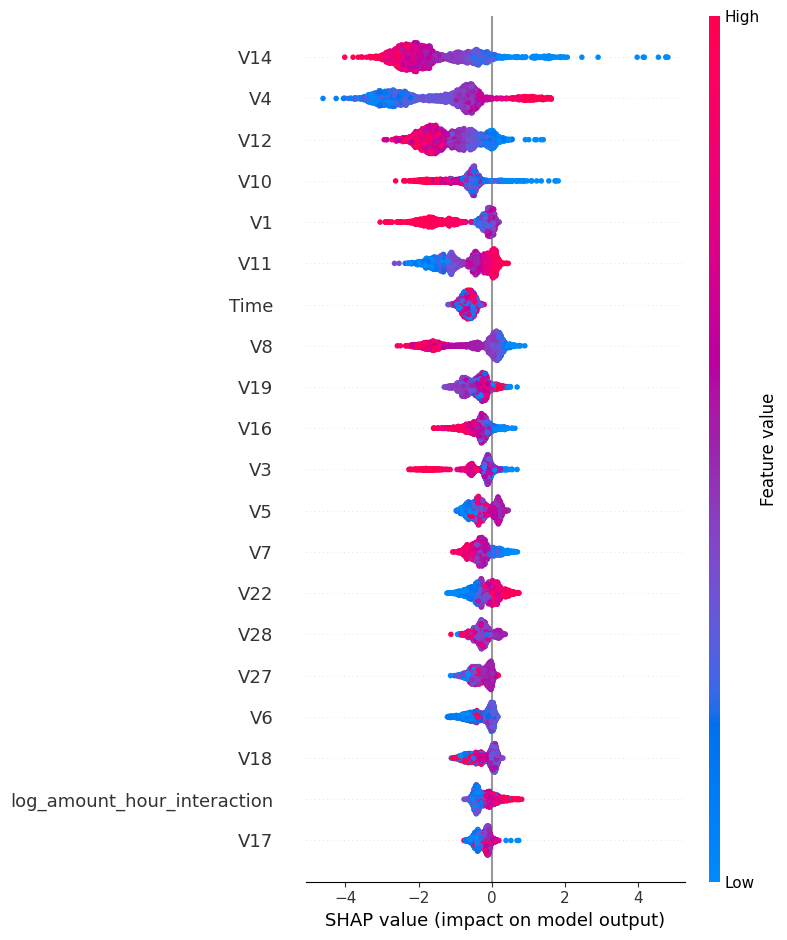

In [9]:
plt.figure()
shap.summary_plot(
    shap_values_class1,
    X_shap_sample,
    max_display=20,
    show=False,
)
plt.savefig(REPORT_DIR / "shap_summary_plot.png", dpi=400, bbox_inches="tight")
plt.show()

### How to Explain the SHAP Summary Plot in the Thesis

This plot should be described as evidence that the model relies on a combination of anonymized PCA features and engineered behavioral features. Avoid causal language. For example, write `V14 strongly contributes to the model's fraud prediction`, not `V14 causes fraud`.

## 8.2. SHAP Bar Plot

The SHAP bar plot shows the mean absolute SHAP value for each feature. It is easier to include in a report because it ranks the most influential features without showing every individual data point.

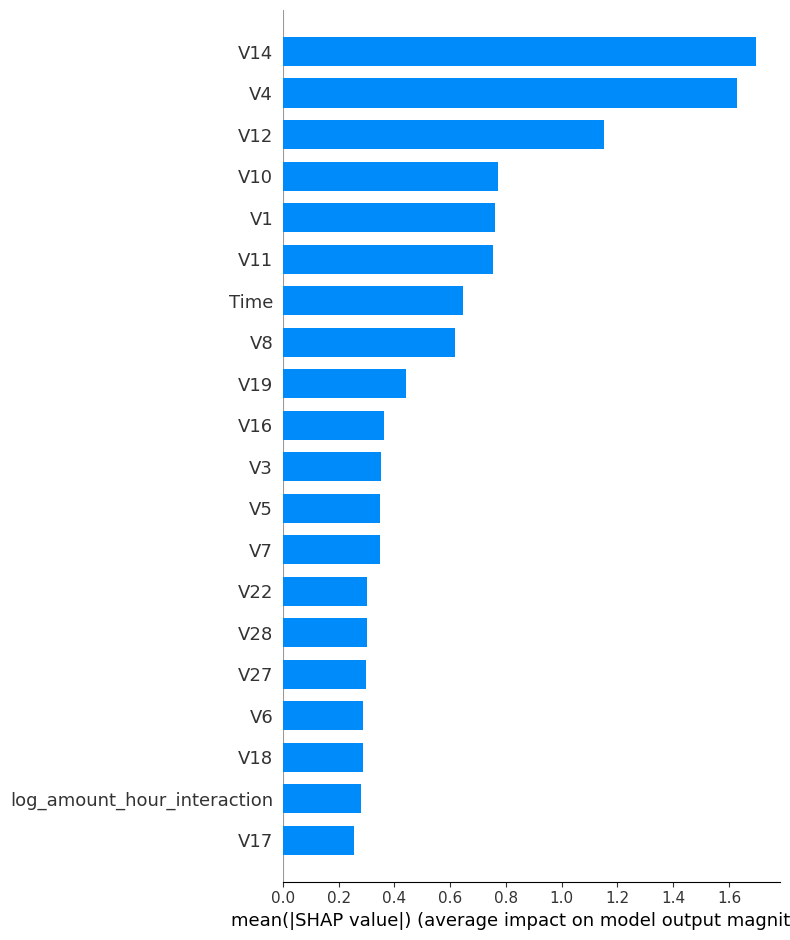

In [10]:
plt.figure()
shap.summary_plot(
    shap_values_class1,
    X_shap_sample,
    plot_type="bar",
    max_display=20,
    show=False,
)
plt.savefig(REPORT_DIR / "shap_bar_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### How to Interpret the SHAP Bar Plot

The top features have the strongest average contribution to the model's output. This does not mean these features are causal. It means the trained XGBoost model uses them heavily when ranking fraud risk.

## 9. SHAP Local Explanation for Selected Cases

Local SHAP explanations show which features pushed a single transaction toward fraud or non-fraud. This notebook uses top contribution tables and bar plots because they are stable, easy to save, and easy to discuss in the thesis.

In [11]:
def get_case_shap_values(case_df):
    case_features = case_df[feature_list]
    values, bias_values = compute_xgb_shap_contributions(case_features)
    return case_features, values[0], bias_values[0]


def shap_top_contributions(case_df, case_name, top_n=10):
    case_features, values, bias_value = get_case_shap_values(case_df)

    contrib_df = pd.DataFrame({
        "feature": feature_list,
        "feature_value": case_features.iloc[0].values,
        "shap_value": values,
    })
    contrib_df["abs_shap"] = contrib_df["shap_value"].abs()
    contrib_df = contrib_df.sort_values("abs_shap", ascending=False)

    output_path = REPORT_DIR / f"{case_name}_shap_contributions.csv"
    contrib_df.to_csv(output_path, index=False)

    plot_df = contrib_df.head(top_n).sort_values("shap_value")
    colors = np.where(plot_df["shap_value"] >= 0, "#d62728", "#1f77b4")

    plt.figure(figsize=(8, 5))
    plt.barh(plot_df["feature"], plot_df["shap_value"], color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.xlabel("SHAP contribution to fraud log-odds")
    plt.title(f"Top SHAP Contributions - {case_name}")
    plt.tight_layout()
    plt.savefig(REPORT_DIR / f"{case_name}_shap_contributions.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Case: {case_name}")
    print("Actual:", int(case_df["actual"].iloc[0]))
    print("Predicted:", int(case_df["predicted"].iloc[0]))
    print("Fraud probability:", float(case_df["fraud_probability"].iloc[0]))
    print("SHAP bias term:", float(bias_value))

    return contrib_df

### How to Read Local SHAP Contribution Tables

Positive SHAP contributions push the model toward fraud. Negative SHAP contributions push the model toward non-fraud. Because native XGBoost SHAP values are in log-odds space, focus on direction and relative magnitude rather than reading them as direct probability changes.

## 9.1. True Positive SHAP Explanation

This case is a real fraud transaction that the model correctly detected. The explanation should highlight which features pushed the fraud probability above the threshold.

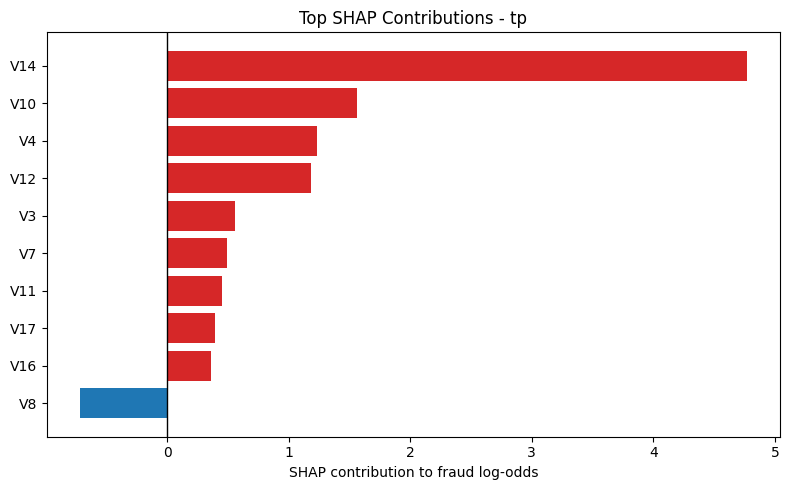

Case: tp
Actual: 1
Predicted: 1
Fraud probability: 0.9999818801879883
SHAP bias term: 2.7216687202453613


,feature,feature_value,shap_value,abs_shap
14,V14,-9.150951,4.767580,4.767580
10,V10,-4.063098,1.562247,1.562247
4,V4,6.009415,1.230800,1.230800
12,V12,-6.151362,1.184170,1.184170
8,V8,0.338527,-0.714638,0.714638
3,V3,-5.647343,0.559623,0.559623
7,V7,-1.819308,0.495696,0.495696
11,V11,2.941190,0.453270,0.453270
17,V17,-2.892555,0.391064,0.391064
16,V16,-1.952290,0.357384,0.357384


In [12]:
tp_shap_contrib = shap_top_contributions(tp_case, "tp", top_n=10)
tp_shap_contrib.head(10)

### True Positive Interpretation

For a true positive, the most important positive SHAP values explain why the model caught the fraud. In the report, describe anonymized PCA features as hidden transaction patterns and engineered variables as behavioral signals. Do not assign real-world meanings to `V1-V28`.

## 9.2. False Negative SHAP Explanation

This case is a real fraud transaction that the model missed. It is especially important because it shows the model's limitation.

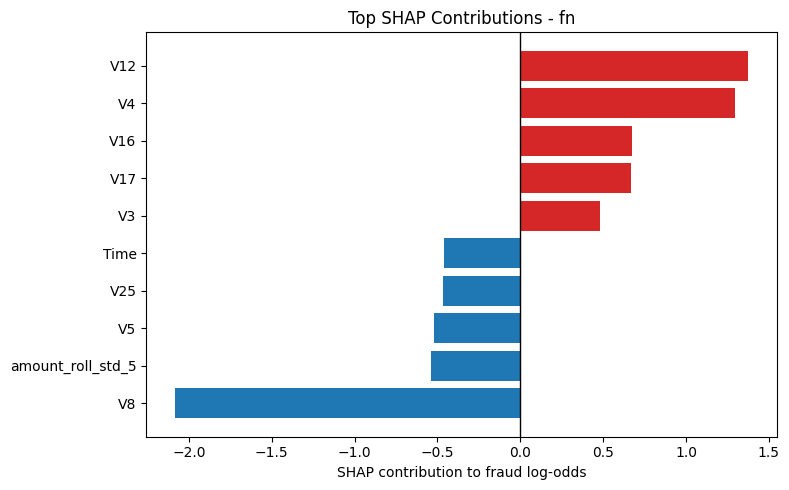

Case: fn
Actual: 1
Predicted: 0
Fraud probability: 0.5761077404022217
SHAP bias term: 2.7216687202453613


,feature,feature_value,shap_value,abs_shap
8,V8,0.474858,-2.083718,2.083718
12,V12,-3.259702,1.373587,1.373587
4,V4,6.249462,1.293207,1.293207
16,V16,-2.986920,0.672737,0.672737
17,V17,-4.815863,0.665341,0.665341
37,amount_roll_std_5,427.582606,-0.536681,0.536681
5,V5,-3.360922,-0.520575,0.520575
3,V3,-3.829762,0.477937,0.477937
25,V25,0.538710,-0.469411,0.469411
0,Time,147501.000000,-0.462090,0.462090


In [13]:
fn_shap_contrib = shap_top_contributions(fn_case, "fn", top_n=10)
fn_shap_contrib.head(10)

### False Negative Interpretation

For a false negative, look for features with negative SHAP values or weak positive evidence. This helps explain why the fraud probability stayed below the threshold. These cases are useful for discussing model limitations and possible future improvements.

## 9.3. False Positive SHAP Explanation

This case is a normal transaction that the model incorrectly flagged as fraud. It helps explain why some legitimate transactions may look suspicious to the model.

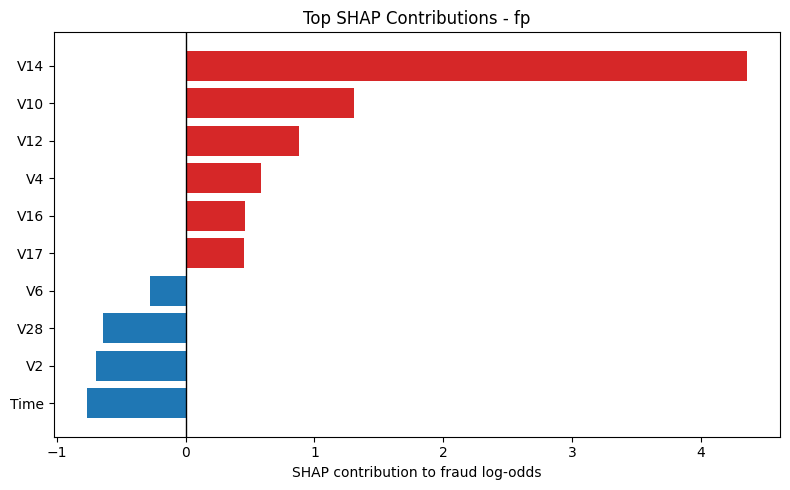

Case: fp
Actual: 0
Predicted: 1
Fraud probability: 0.9991968274116516
SHAP bias term: 2.7216687202453613


,feature,feature_value,shap_value,abs_shap
14,V14,-3.786058,4.356788,4.356788
10,V10,-2.566471,1.307153,1.307153
12,V12,-2.651618,0.877986,0.877986
0,Time,166023.000000,-0.767625,0.767625
2,V2,1.825168,-0.695465,0.695465
28,V28,0.475417,-0.638133,0.638133
4,V4,2.008922,0.587853,0.587853
16,V16,-2.152230,0.460332,0.460332
17,V17,-1.862707,0.455234,0.455234
6,V6,-2.078762,-0.278094,0.278094


In [14]:
fp_shap_contrib = shap_top_contributions(fp_case, "fp", top_n=10)
fp_shap_contrib.head(10)

### False Positive Interpretation

For a false positive, positive SHAP values show which features created a fraud-like pattern. From a business perspective, this type of error can create unnecessary alerts, but the low number of false positives suggests that the selected threshold controls alert volume well.

## 10. LIME Local Explanation

LIME explains individual predictions by fitting a simpler local surrogate model around a selected transaction. In this project, LIME is used as a complementary explanation method, while SHAP remains the primary method for XGBoost.

In [15]:
X_train_lime_sample = X_train.sample(n=min(5000, len(X_train)), random_state=42)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime_sample.values,
    feature_names=feature_list,
    class_names=["Non-fraud", "Fraud"],
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)


def lime_predict_proba(rows):
    rows_df = pd.DataFrame(rows, columns=feature_list)
    return model.predict_proba(rows_df)

print("LIME training sample:", X_train_lime_sample.shape)

LIME training sample: (5000, 47)


### How to Interpret LIME Setup

LIME uses a smaller training sample to approximate the model locally. The prediction function wraps rows back into a DataFrame with the correct feature names, which avoids feature-order issues when calling the XGBoost model.

In [16]:
def explain_case_with_lime(case_df, case_name, num_features=10):
    case_features = case_df[feature_list].iloc[0].values

    exp = lime_explainer.explain_instance(
        data_row=case_features,
        predict_fn=lime_predict_proba,
        num_features=num_features,
    )

    lime_df = pd.DataFrame(exp.as_list(), columns=["feature_condition", "lime_weight"])
    lime_df.to_csv(REPORT_DIR / f"lime_{case_name}.csv", index=False)

    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Explanation - {case_name}")
    plt.tight_layout()
    plt.savefig(REPORT_DIR / f"lime_{case_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Case: {case_name}")
    print("Actual:", int(case_df["actual"].iloc[0]))
    print("Predicted:", int(case_df["predicted"].iloc[0]))
    print("Fraud probability:", float(case_df["fraud_probability"].iloc[0]))

    return lime_df

## 10.1. LIME Explanation for True Positive

This LIME explanation provides a second local view of why the correctly detected fraud case was classified as fraud.

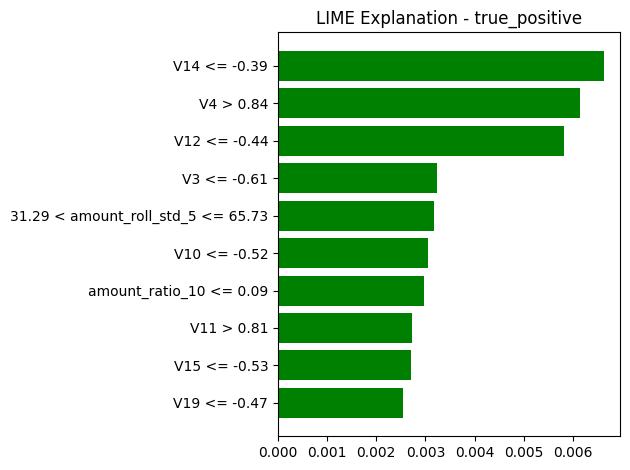

Case: true_positive
Actual: 1
Predicted: 1
Fraud probability: 0.9999818801879883


,feature_condition,lime_weight
0,V14 <= -0.39,0.006628
1,V4 > 0.84,0.006152
2,V12 <= -0.44,0.005818
3,V3 <= -0.61,0.003242
4,31.29 < amount_roll_std_5 <= 65.73,0.003183
5,V10 <= -0.52,0.003056
6,amount_ratio_10 <= 0.09,0.002973
7,V11 > 0.81,0.002739
8,V15 <= -0.53,0.002707
9,V19 <= -0.47,0.002539


In [17]:
tp_lime = explain_case_with_lime(tp_case, "true_positive")
tp_lime

## 10.2. LIME Explanation for False Negative

This LIME explanation helps inspect why a fraudulent transaction was not flagged by the final threshold.

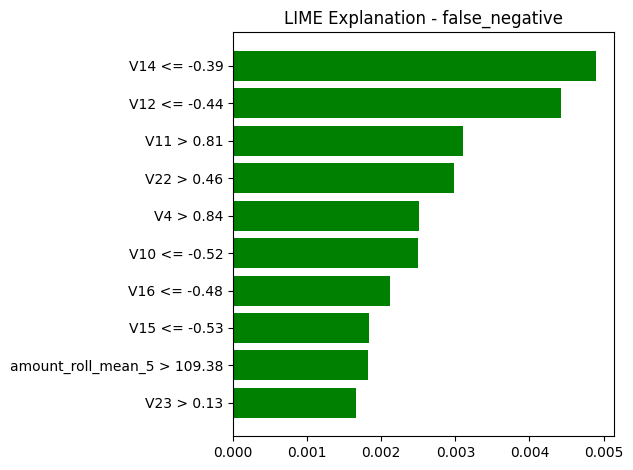

Case: false_negative
Actual: 1
Predicted: 0
Fraud probability: 0.5761077404022217


,feature_condition,lime_weight
0,V14 <= -0.39,0.004900
1,V12 <= -0.44,0.004431
2,V11 > 0.81,0.003097
3,V22 > 0.46,0.002980
4,V4 > 0.84,0.002510
5,V10 <= -0.52,0.002492
6,V16 <= -0.48,0.002111
7,V15 <= -0.53,0.001834
8,amount_roll_mean_5 > 109.38,0.001814
9,V23 > 0.13,0.001663


In [18]:
fn_lime = explain_case_with_lime(fn_case, "false_negative")
fn_lime

## 10.3. LIME Explanation for False Positive

This LIME explanation helps inspect why a legitimate transaction looked risky enough to be flagged as fraud.

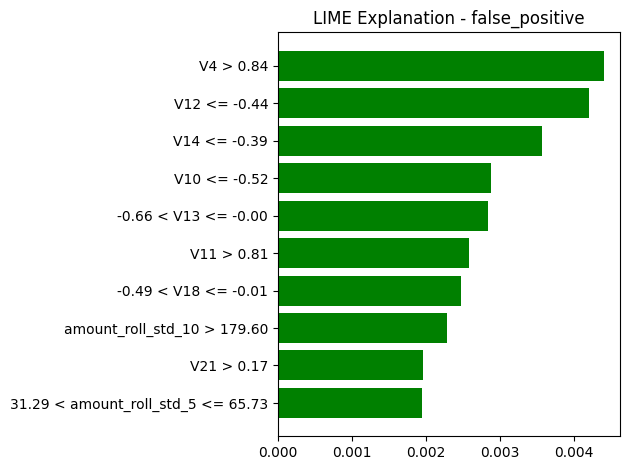

Case: false_positive
Actual: 0
Predicted: 1
Fraud probability: 0.9991968274116516


,feature_condition,lime_weight
0,V4 > 0.84,0.004398
1,V12 <= -0.44,0.004195
2,V14 <= -0.39,0.003569
3,V10 <= -0.52,0.002870
4,-0.66 < V13 <= -0.00,0.002842
5,V11 > 0.81,0.002574
6,-0.49 < V18 <= -0.01,0.002470
7,amount_roll_std_10 > 179.60,0.002283
8,V21 > 0.17,0.001959
9,31.29 < amount_roll_std_5 <= 65.73,0.001947


In [19]:
fp_lime = explain_case_with_lime(fp_case, "false_positive")
fp_lime

### How to Interpret LIME Tables and Plots

Positive LIME weights support the fraud class, while negative weights support the non-fraud class. LIME explanations can vary because they are based on local perturbations, so they should be used as supporting evidence rather than the only explanation.

## 11. SHAP vs LIME Interpretation

SHAP and LIME answer similar local explanation questions but use different logic. SHAP decomposes the prediction into feature contributions based on game theory, while LIME fits a local surrogate model around the selected transaction.

In [20]:
method_comparison = pd.DataFrame([
    {
        "Aspect": "Explanation level",
        "SHAP": "Global and local",
        "LIME": "Mainly local",
    },
    {
        "Aspect": "Suitability for XGBoost",
        "SHAP": "Highly suitable for tree-based models",
        "LIME": "Suitable as a complementary method",
    },
    {
        "Aspect": "Interpretation logic",
        "SHAP": "Feature contribution to model output",
        "LIME": "Local surrogate explanation around one instance",
    },
    {
        "Aspect": "Role in this project",
        "SHAP": "Primary explanation method",
        "LIME": "Supporting explanation method",
    },
])

method_comparison.to_csv(REPORT_DIR / "shap_lime_method_comparison.csv", index=False)
method_comparison

,Aspect,SHAP,LIME
0,Explanation level,Global and local,Mainly local
1,Suitability for XGBoost,Highly suitable for tree-based models,Suitable as a complementary method
2,Interpretation logic,Feature contribution to model output,Local surrogate explanation around one instance
3,Role in this project,Primary explanation method,Supporting explanation method


### How to Use This Comparison in the Thesis

SHAP should be presented as the main XAI method for the final XGBoost model. LIME should be presented as an additional local explanation method that helps validate whether selected cases show similar explanation patterns.

## 11.1. Comparison between SHAP and LIME

| Aspect | SHAP | LIME |
|---|---|---|
| Explanation level | Global and local | Mainly local |
| Suitability for XGBoost | Highly suitable for tree-based models | Suitable as a complementary method |
| Interpretation logic | Feature contribution to model output | Local surrogate explanation around one instance |
| Role in this project | Primary explanation method | Supporting explanation method |

SHAP is used as the primary explanation method because it provides consistent contribution values for the XGBoost model and supports both global and local interpretation. LIME is used as a complementary method because it gives a second local view of individual predictions.

## 11.2. Borderline Case Near the Decision Threshold

The three main explanation cases cover a correct fraud detection, a missed fraud, and a false alert. To make the analysis deeper, this section adds one borderline transaction whose fraud probability is closest to the final threshold of `0.73`.

Borderline cases are useful because they show where the system has the most difficulty making a confident decision. A small change in threshold could change the final prediction for these transactions.

In [21]:
borderline_cases = test_analysis_df.copy()
borderline_cases["distance_to_threshold"] = (
    borderline_cases["fraud_probability"] - threshold
).abs()

borderline_case = borderline_cases.sort_values("distance_to_threshold").head(1)

borderline_summary = borderline_case[
    ["actual", "predicted", "fraud_probability", "distance_to_threshold"]
].copy()

borderline_case.to_csv(REPORT_DIR / "borderline_case.csv", index=False)
borderline_summary

,actual,predicted,fraud_probability,distance_to_threshold
9346,0,1,0.766567,0.036567


### Borderline Case Interpretation

If the fraud probability is very close to `0.73`, the model is near its decision boundary. This does not indicate a code error. It indicates that the transaction contains mixed signals and that the threshold selection directly affects the final fraud/non-fraud decision.

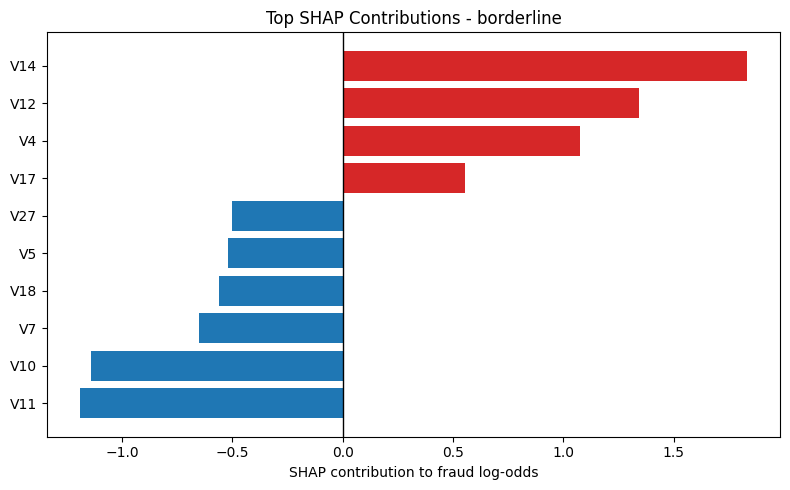

Case: borderline
Actual: 0
Predicted: 1
Fraud probability: 0.766566812992096
SHAP bias term: 2.7216687202453613


,feature,feature_value,shap_value,abs_shap
14,V14,-2.215909,1.829844,1.829844
12,V12,-3.800168,1.344328,1.344328
11,V11,-0.285980,-1.188538,1.188538
10,V10,-0.518420,-1.141217,1.141217
4,V4,5.993927,1.076174,1.076174
7,V7,3.109868,-0.648678,0.648678
18,V18,-1.401269,-0.559847,0.559847
17,V17,-4.281976,0.551880,0.551880
5,V5,-3.236609,-0.520765,0.520765
27,V27,1.175075,-0.502671,0.502671


In [22]:
borderline_shap_contrib = shap_top_contributions(borderline_case, "borderline", top_n=10)
borderline_shap_contrib.head(10)

## 11.3. Interpretation of Explainability Results

The SHAP global explanation shows that the final XGBoost model relies mainly on anonymized PCA-transformed features, especially `V14`, `V4`, `V12`, and `V10`. These features have the largest average impact on the model output. Since the dataset is anonymized, these PCA features cannot be directly mapped to specific financial or customer attributes. Therefore, they should be interpreted only as transformed transaction patterns that are useful for distinguishing fraudulent and non-fraudulent transactions.

The SHAP local explanations provide further insight into individual predictions. For the true positive case, several important PCA features strongly pushed the prediction toward fraud, resulting in a very high fraud probability. For the false negative case, the model assigned a moderate fraud probability, but it did not exceed the selected threshold of `0.73`. This shows that the missed fraud case contained some fraud-like signals but was not strong enough to trigger a fraud alert. For the false positive case, the explanation shows that a normal transaction shared several feature patterns with fraudulent cases, causing the model to incorrectly flag it as fraud.

LIME was used as a complementary local explanation method. The LIME results were generally consistent with SHAP, as both methods highlighted similar features such as `V14`, `V4`, `V12`, `V10`, and `V11`. This consistency supports the reliability of the explanation results. However, SHAP is used as the primary explanation method in this project because it is more suitable for tree-based models and provides both global and local explanations.

Overall, the explainability analysis confirms that the model does not operate as a pure black box. It also shows that both correctly classified and misclassified transactions can be examined in detail, which is important for financial risk management and future simulated real-time fraud detection deployment.

### Limitations and Reporting Notes

- SHAP values are in log-odds contribution space, not direct probability changes.
- PCA features `V1-V28` cannot be interpreted as original business variables.
- SHAP and LIME explain model behavior; they do not prove causal relationships.
- False negatives still exist and should be monitored in future model iterations.
- The false negative case with probability below `0.73` is consistent with the selected threshold and is not a contradiction.

## 11.4. Required Output File Check

This cell verifies the minimum required Week 5 files listed in the review note. If `all_present` is `True`, the explainability outputs are sufficiently saved for reporting.

In [23]:
required_outputs = [
    "shap_summary_plot.png",
    "shap_bar_plot.png",
    "tp_shap_contributions.csv",
    "fn_shap_contributions.csv",
    "fp_shap_contributions.csv",
    "lime_true_positive.csv",
    "lime_false_negative.csv",
    "lime_false_positive.csv",
    "explanation_case_summary.csv",
]

required_output_check = pd.DataFrame([
    {
        "file": file,
        "exists": (REPORT_DIR / file).exists(),
        "size_bytes": (REPORT_DIR / file).stat().st_size if (REPORT_DIR / file).exists() else 0,
    }
    for file in required_outputs
])

all_present = required_output_check["exists"].all()
print("All required Week 5 outputs present:", all_present)

required_output_check

All required Week 5 outputs present: True


,file,exists,size_bytes
0,shap_summary_plot.png,True,679396
1,shap_bar_plot.png,True,119380
2,tp_shap_contributions.csv,True,2230
3,fn_shap_contributions.csv,True,2217
4,fp_shap_contributions.csv,True,2271
5,lime_true_positive.csv,True,410
6,lime_false_negative.csv,True,392
7,lime_false_positive.csv,True,433
8,explanation_case_summary.csv,True,764


## 12. Save Final Explanation Output Index

This cell lists the files created by the notebook. It is a practical checklist for confirming that Week 5 has produced all required artifacts.

In [24]:
output_files = sorted(path.name for path in REPORT_DIR.glob("*"))

output_index = pd.DataFrame({
    "file": output_files,
    "path": [str(REPORT_DIR / file) for file in output_files],
})

output_index.to_csv(REPORT_DIR / "explainability_output_index.csv", index=False)
output_index

,file,path
0,borderline_case.csv,..\reports\explainability\borderline_case.csv
1,borderline_shap_contributions.csv,..\reports\explainability\borderline_shap_cont...
2,borderline_shap_contributions.png,..\reports\explainability\borderline_shap_cont...
3,classification_report.csv,..\reports\explainability\classification_repor...
4,explainability_output_index.csv,..\reports\explainability\explainability_outpu...
5,explanation_case_summary.csv,..\reports\explainability\explanation_case_sum...
6,false_negatives_cases.csv,..\reports\explainability\false_negatives_case...
7,false_positives_cases.csv,..\reports\explainability\false_positives_case...
8,fn_shap_contributions.csv,..\reports\explainability\fn_shap_contribution...
9,fn_shap_contributions.png,..\reports\explainability\fn_shap_contribution...


## 13. Thesis Summary Notes

In this stage, Explainable AI techniques were applied to the final XGBoost fraud detection model. SHAP was used as the primary explanation method because it provides both global and local interpretability for tree-based models. The global SHAP analysis identifies the most influential features contributing to fraud prediction, including anonymized PCA features and selected engineered behavioral variables.

Local explanations were generated for four representative cases: a correctly detected fraudulent transaction, a missed fraudulent transaction, a normal transaction incorrectly flagged as fraud, and a borderline transaction close to the decision threshold. These cases help illustrate how the model behaves under different prediction outcomes and provide insight into both its strengths and limitations.

LIME was also applied as a complementary local explanation method. While SHAP provides more consistent explanations for the XGBoost model, LIME offers an additional perspective on individual predictions. The LIME results generally support the SHAP findings because both methods highlight similar PCA-transformed features such as `V14`, `V4`, `V12`, `V10`, and `V11`.

Overall, the explainability analysis improves the transparency of the fraud detection system and prepares the model for subsequent deployment in a simulated real-time inference pipeline.

Important reporting cautions:

- Do not interpret `V1-V28` as real business variables; they are anonymized PCA-transformed features.
- Do not claim SHAP proves causality; SHAP explains model contribution to a prediction.
- Do not describe the current notebook as a real-time system; it is an offline explainability analysis for the final model.
- Mention that SHAP contributions are in log-odds space, not direct probability changes.